In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud

In [7]:
# Lee el archivo XML
df = pd.read_xml('../data/raw/Posts.xml')

# Muestra las primeras filas
df.head()

,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,LastEditorUserId,LastEditDate,...,Tags,AnswerCount,CommentCount,ContentLicense,ParentId,LastEditorDisplayName,ClosedDate,FavoriteCount,OwnerDisplayName,CommunityOwnedDate
0,1,1,161.0,2010-08-05T19:34:49.473,59,188045.0,<p>When should I use <em>can</em>? When should...,9.0,300.0,2013-01-24T22:00:48.513,...,|word-choice|tenses|politeness|subjunctive-moo...,6.0,0,CC BY-SA 3.0,NaN,None,None,NaN,None,None
1,2,1,12.0,2010-08-05T19:37:29.890,61,51713.0,"<p>Doesn't ""quint"" mean ""five""? What does tha...",16.0,9001.0,2016-12-19T20:32:34.127,...,|meaning|etymology|,7.0,5,CC BY-SA 2.5,NaN,None,None,NaN,None,None
2,3,1,NaN,2010-08-05T19:39:40.743,68,35015.0,<p>Which is the correct use of these two words...,13078.0,9001.0,2016-12-19T20:32:55.093,...,|differences|future|will-future|shall-future|,10.0,8,CC BY-SA 3.0,NaN,None,None,NaN,None,None
3,5,2,NaN,2010-08-05T19:40:58.213,6,NaN,"<p>It's the fifth element after earth, air, fi...",21.0,NaN,None,...,None,NaN,0,CC BY-SA 2.5,2.0,None,None,NaN,None,None
4,6,1,10600.0,2010-08-05T19:41:04.000,30,6852.0,"<p>I think most folk happily use either ""while...",15.0,77227.0,2017-07-29T01:17:16.993,...,|word-choice|etymology|differences|conjunction...,9.0,6,CC BY-SA 2.5,NaN,None,None,NaN,None,None


In [8]:
df.count()

Id                       425573
PostTypeId               425573
AcceptedAnswerId          62199
CreationDate             425573
Score                    425573
ViewCount                130631
Body                     425286
OwnerUserId              409400
LastEditorUserId         181127
LastEditDate             188039
LastActivityDate         425573
Title                    130631
Tags                     130631
AnswerCount              130631
CommentCount             425573
ContentLicense           425573
ParentId                 293544
LastEditorDisplayName      8279
ClosedDate                35307
FavoriteCount              3032
OwnerDisplayName          17033
CommunityOwnedDate         1894
dtype: int64

In [13]:
df.tail()

,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,LastEditorUserId,LastEditDate,...,Tags,AnswerCount,CommentCount,ContentLicense,ParentId,LastEditorDisplayName,ClosedDate,FavoriteCount,OwnerDisplayName,CommunityOwnedDate
425568,621068,1,NaN,2024-03-31T22:44:12.233,1,49.0,<p>In a family with multiple married adult chi...,325064.0,325064.0,2024-04-04T17:55:03.833,...,|single-word-requests|phrase-requests|,1.0,4,CC BY-SA 4.0,NaN,None,None,NaN,None,None
425569,621069,1,NaN,2024-03-31T22:51:42.820,-1,25.0,<p>I'm writing documentation for a software li...,501000.0,501000.0,2024-04-01T16:54:33.727,...,|meaning|,1.0,4,CC BY-SA 4.0,NaN,None,2024-03-31T23:43:35.760,NaN,None,None
425570,621070,2,NaN,2024-03-31T23:27:26.037,2,NaN,<p>I have thought such things myself.</p>\n<p>...,330962.0,330962.0,2024-04-01T13:31:26.510,...,None,NaN,1,CC BY-SA 4.0,611718.0,None,None,NaN,None,None
425571,621071,2,NaN,2024-03-31T23:40:27.007,1,NaN,"<p>Here's <a href=""https://books.google.com/ng...",2637.0,NaN,None,...,None,NaN,0,CC BY-SA 4.0,621069.0,None,None,NaN,None,None
425572,621072,2,NaN,2024-03-31T23:54:40.843,0,NaN,"<p>Maybe, [family name], in-laws, and plus-one...",437316.0,NaN,None,...,None,NaN,1,CC BY-SA 4.0,621068.0,None,None,NaN,None,None


In [ ]:
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425573 entries, 0 to 425572
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Id                     425573 non-null  int64  
 1   PostTypeId             425573 non-null  int64  
 2   AcceptedAnswerId       62199 non-null   float64
 3   CreationDate           425573 non-null  object 
 4   Score                  425573 non-null  int64  
 5   ViewCount              130631 non-null  float64
 6   Body                   425286 non-null  object 
 7   OwnerUserId            409400 non-null  float64
 8   LastEditorUserId       181127 non-null  float64
 9   LastEditDate           188039 non-null  object 
 10  LastActivityDate       425573 non-null  object 
 11  Title                  130631 non-null  object 
 12  Tags                   130631 non-null  object 
 13  AnswerCount            130631 non-null  float64
 14  CommentCount           425573 non-nu

,Id,PostTypeId,AcceptedAnswerId,Score,ViewCount,OwnerUserId,LastEditorUserId,AnswerCount,CommentCount,ParentId,FavoriteCount
count,425573.000000,425573.000000,62199.000000,425573.000000,1.306310e+05,409400.000000,181127.000000,130631.000000,425573.000000,293544.000000,3032.000000
mean,294849.722449,1.701428,267537.861316,3.394783,9.529579e+03,128344.771072,83828.094944,2.247361,2.222216,266003.665904,0.001319
std,181566.876230,0.490217,182201.288549,8.666625,4.015892e+04,128352.255689,114854.353375,2.205034,3.108413,179512.090982,0.036304
min,1.000000,1.000000,12.000000,-69.000000,6.000000e+00,-1.000000,-1.000000,0.000000,0.000000,1.000000,0.000000
25%,138134.000000,1.000000,102446.000000,0.000000,1.890000e+02,18981.000000,2085.000000,1.000000,0.000000,107522.500000,0.000000
50%,284771.000000,2.000000,250484.000000,1.000000,9.310000e+02,83537.000000,26083.000000,2.000000,1.000000,249704.500000,0.000000
75%,453442.000000,2.000000,424197.000000,3.000000,4.366500e+03,196213.500000,127726.000000,3.000000,3.000000,413399.250000,0.000000
max,621072.000000,7.000000,621008.000000,822.000000,2.321634e+06,501000.000000,501000.000000,124.000000,69.000000,621069.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425573 entries, 0 to 425572
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Id                     425573 non-null  int64  
 1   PostTypeId             425573 non-null  int64  
 2   AcceptedAnswerId       62199 non-null   float64
 3   CreationDate           425573 non-null  object 
 4   Score                  425573 non-null  int64  
 5   ViewCount              130631 non-null  float64
 6   Body                   425286 non-null  object 
 7   OwnerUserId            409400 non-null  float64
 8   LastEditorUserId       181127 non-null  float64
 9   LastEditDate           188039 non-null  object 
 10  LastActivityDate       425573 non-null  object 
 11  Title                  130631 non-null  object 
 12  Tags                   130631 non-null  object 
 13  AnswerCount            130631 non-null  float64
 14  CommentCount           425573 non-nu

In [15]:
df.describe(include='all')

,Id,PostTypeId,AcceptedAnswerId,CreationDate,Score,ViewCount,Body,OwnerUserId,LastEditorUserId,LastEditDate,...,Tags,AnswerCount,CommentCount,ContentLicense,ParentId,LastEditorDisplayName,ClosedDate,FavoriteCount,OwnerDisplayName,CommunityOwnedDate
count,425573.000000,425573.000000,62199.000000,425573,425573.000000,1.306310e+05,425286,409400.000000,181127.000000,188039,...,130631,130631.000000,425573.000000,425573,293544.000000,8279,35307,3032.000000,17033,1894
unique,NaN,NaN,NaN,424797,NaN,NaN,425257,NaN,NaN,157332,...,39992,NaN,NaN,3,NaN,626,35307,NaN,2968,1667
top,NaN,NaN,NaN,2015-01-28T10:31:04.623,NaN,NaN,<p>I would go for <strong>the one challenged</...,NaN,NaN,2020-06-15T07:40:02.530,...,|single-word-requests|,NaN,NaN,CC BY-SA 3.0,NaN,user66974,2024-03-31T23:43:35.760,NaN,user66974,2014-03-13T03:06:51.137
freq,NaN,NaN,NaN,2,NaN,NaN,2,NaN,NaN,23557,...,8485,NaN,NaN,293251,NaN,1743,1,NaN,3538,31
mean,294849.722449,1.701428,267537.861316,NaN,3.394783,9.529579e+03,NaN,128344.771072,83828.094944,NaN,...,NaN,2.247361,2.222216,NaN,266003.665904,NaN,NaN,0.001319,NaN,NaN
std,181566.876230,0.490217,182201.288549,NaN,8.666625,4.015892e+04,NaN,128352.255689,114854.353375,NaN,...,NaN,2.205034,3.108413,NaN,179512.090982,NaN,NaN,0.036304,NaN,NaN
min,1.000000,1.000000,12.000000,NaN,-69.000000,6.000000e+00,NaN,-1.000000,-1.000000,NaN,...,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,0.000000,NaN,NaN
25%,138134.000000,1.000000,102446.000000,NaN,0.000000,1.890000e+02,NaN,18981.000000,2085.000000,NaN,...,NaN,1.000000,0.000000,NaN,107522.500000,NaN,NaN,0.000000,NaN,NaN
50%,284771.000000,2.000000,250484.000000,NaN,1.000000,9.310000e+02,NaN,83537.000000,26083.000000,NaN,...,NaN,2.000000,1.000000,NaN,249704.500000,NaN,NaN,0.000000,NaN,NaN
75%,453442.000000,2.000000,424197.000000,NaN,3.000000,4.366500e+03,NaN,196213.500000,127726.000000,NaN,...,NaN,3.000000,3.000000,NaN,413399.250000,NaN,NaN,0.000000,NaN,NaN


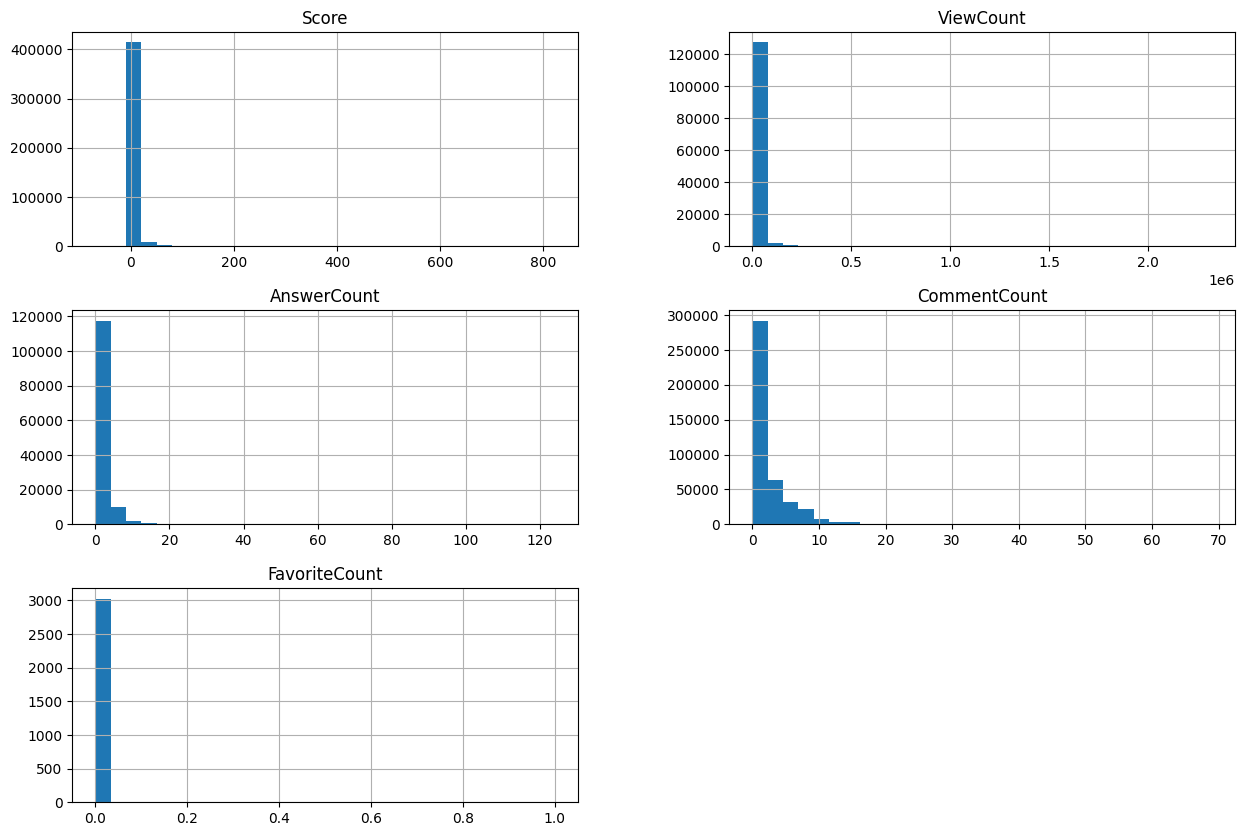

In [16]:
numeric_columns = ['Score', 'ViewCount', 'AnswerCount', 'CommentCount', 'FavoriteCount']
df[numeric_columns].hist(bins=30, figsize=(15, 10))
plt.show()

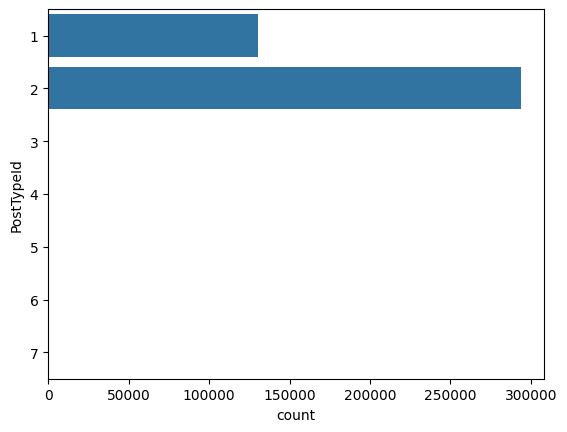

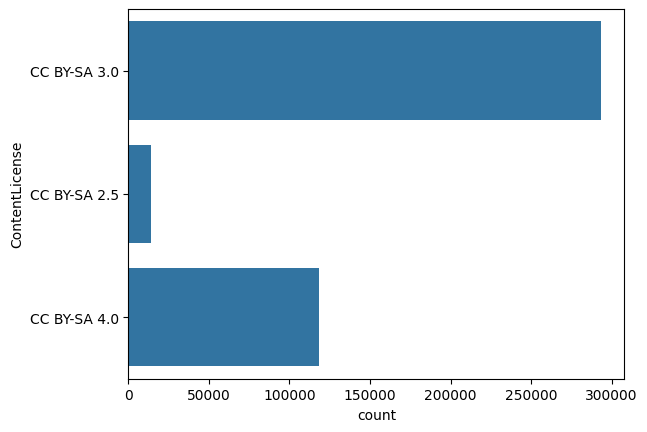

In [17]:
categorical_columns = ['PostTypeId', 'ContentLicense']
for column in categorical_columns:
    sns.countplot(y=column, data=df)
    plt.show()

In [18]:
df.isnull().sum()

Id                            0
PostTypeId                    0
AcceptedAnswerId         363374
CreationDate                  0
Score                         0
ViewCount                294942
Body                        287
OwnerUserId               16173
LastEditorUserId         244446
LastEditDate             237534
LastActivityDate              0
Title                    294942
Tags                     294942
AnswerCount              294942
CommentCount                  0
ContentLicense                0
ParentId                 132029
LastEditorDisplayName    417294
ClosedDate               390266
FavoriteCount            422541
OwnerDisplayName         408540
CommunityOwnedDate       423679
dtype: int64

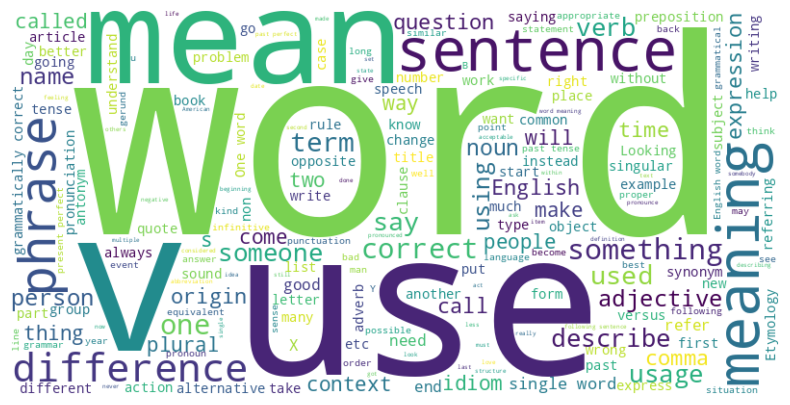

In [25]:
text = ' '.join(df['Title'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

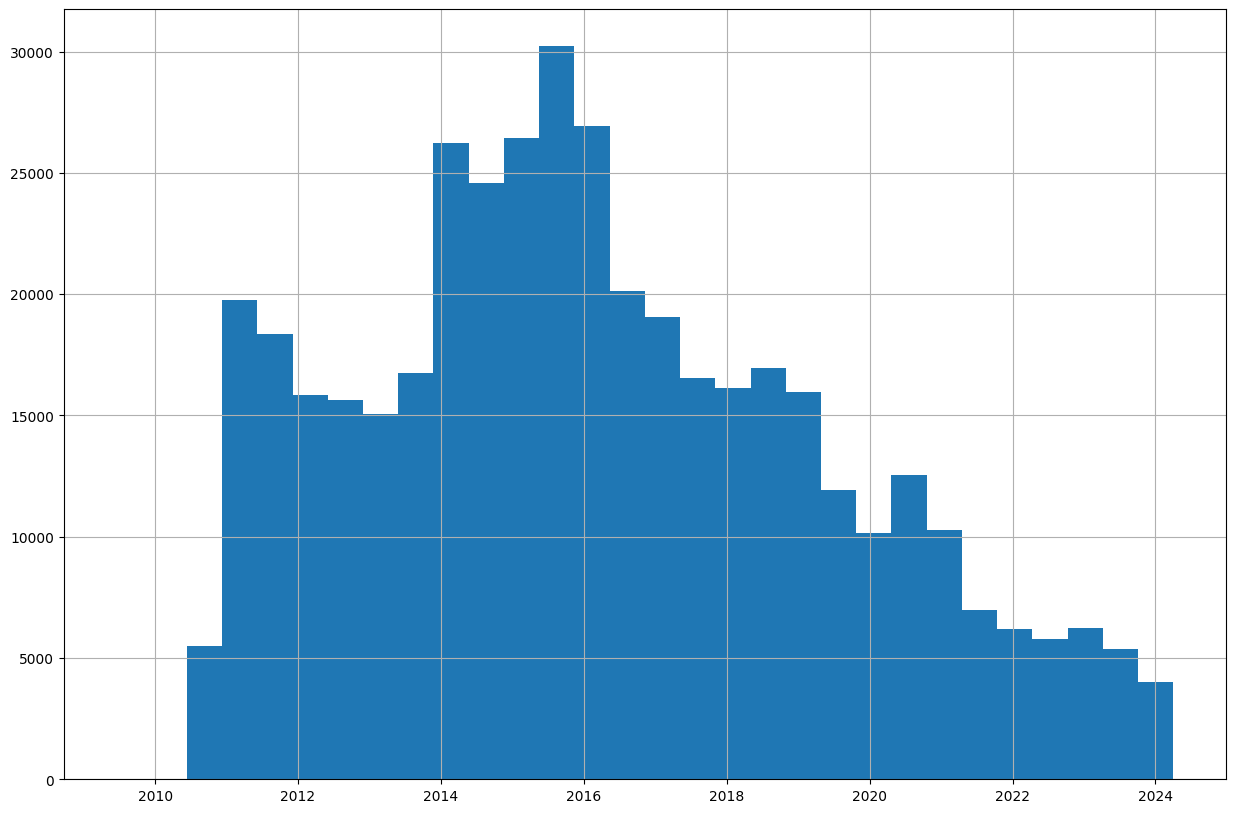

In [26]:
df['CreationDate'] = pd.to_datetime(df['CreationDate'])
df['LastActivityDate'] = pd.to_datetime(df['LastActivityDate'])
df['LastEditDate'] = pd.to_datetime(df['LastEditDate'])
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'])
df['CommunityOwnedDate'] = pd.to_datetime(df['CommunityOwnedDate'])

df['CreationDate'].hist(bins=30, figsize=(15, 10))
plt.show()

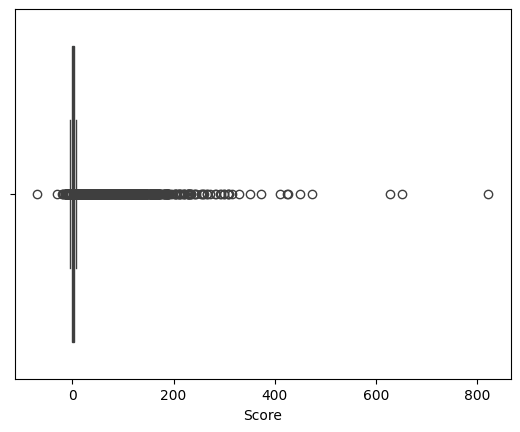

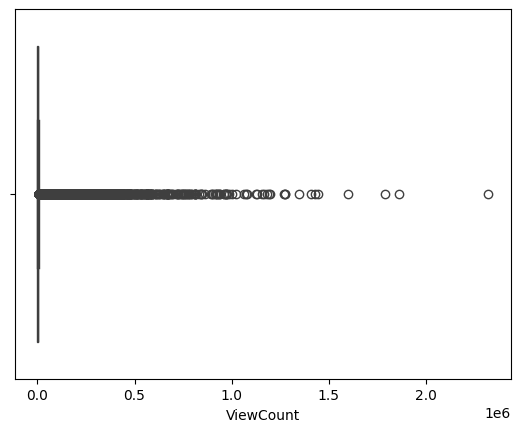

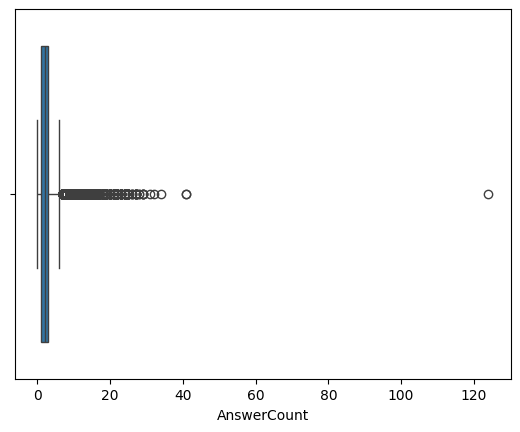

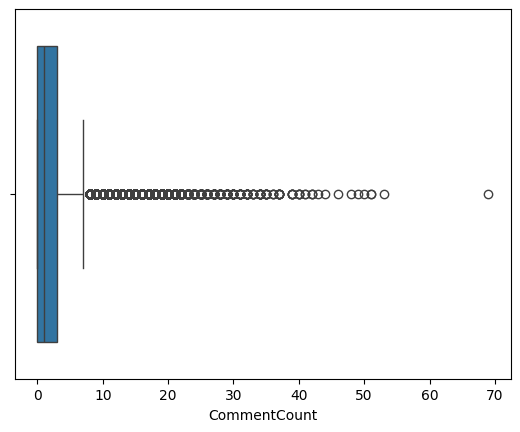

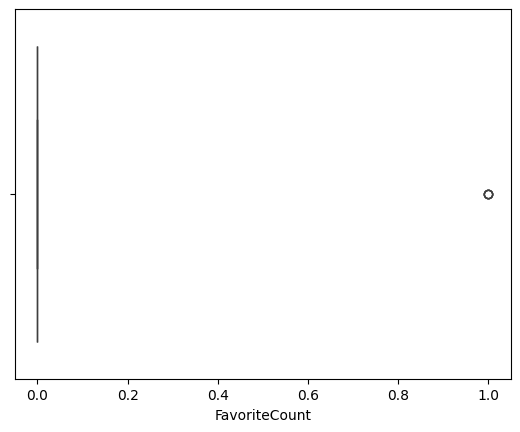

In [27]:
for column in numeric_columns:
    sns.boxplot(x=df[column])
    plt.show()